# ДЗ: ITSM / Customer Support Ticket Routing (Multi-task NLP)
Цель
Построить модель, которая по тексту тикета предсказывает:

queue (52 класса) — основная задача (маршрутизация)
priority (5 классов)
type (5 классов): Incident / Request / Problem / Change / Unknown
где Unknown = отсутствующая разметка type.
Данные
Источник: Hugging Face датасет Tobi-Bueck/customer-support-tickets (61 765 строк, EN/DE).
Используйте поля:

вход: subject, body
лейблы: queue, priority, type
Датасет в репозиторий не кладём. Разбиение фиксируем индексами (см. data/*.txt).

Фиксированный split (обязателен)
Seed: 42, размеры:

train: 49412
val: 6176
test: 6177
Файлы:

data/train_idx.txt
data/val_idx.txt
data/test_idx.txt
Правило: после загрузки датасета берёте строки по row_idx из этих файлов.
Split подготовлен так, что одинаковые тексты (subject+body) не пересекаются между train/val/test.

Что сделать (минимум)
EDA: распределение классов queue, длины текстов.
Baseline: TF-IDF + линейная модель для queue (macro-F1 и accuracy).
Transformer fine-tuning на multitask (queue, priority, type).
...
profit
P.S. а вообще покрутите повертите, хоть LLM хоть KNN можете юзать поощеряется качественное исследование каждого из методов P.P.S. оооочень интересует введение такой метрики как "confidence", например взять 70% наиболее "уверенных" предсказаний и замерить метрику на них, и гипотетически допустить какое будет качество, если 30% ушло бы на ручную разметку (так для всех пропорций посчитать не тока 70/30)

Метрики и скоринг
Считаем метрики на test:

основная: Macro-F1(queue)
дополнительные: Accuracy(queue), Accuracy(priority), Accuracy(type)
Итоговый score:


Score = 0.70 * MacroF1(queue) + 0.15 * Acc(priority) + 0.15 * Acc(type)

Тай-брейк: (1) MacroF1(queue), (2) Acc(queue)

Что сдавать
Праймовый юпитер-ноутбук (где вы постараетесь оформить красиво), у вас могу быть другие юпитеры, но нужно постараться объединить результаты/работу в 1 праймовый (он должен быть полностью запущен и сохранен и желательно без артефактов логов на 100000 строк, читаемый юпитер)
Ссылка на репозиторий с вашим кодом/экспериментами которая сдается через PR к основному репозиторию

# 1. Импорты, инсталлы

In [1]:
!pip install sentencepiece 


In [23]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
from collections import Counter
from sklearn.model_selection import train_test_split
import re
import unicodedata
import time

import numpy as np
import pandas as pd

# Seed
SEED = 42
np.random.seed(SEED)

# ===== Visualization =====
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# ===== HuggingFace =====
from datasets import load_dataset

# ===== Scikit-learn preprocessing =====
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# ===== Scikit-learn models =====
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ===== Scikit-learn wrappers =====
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputClassifier
from sklearn.calibration import CalibratedClassifierCV

# ===== Metrics =====
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from transformers import get_cosine_schedule_with_warmup
from torch.optim import AdamW

# 2. Загрузка датасета с HuggingFace

In [3]:
print('Загружаем датасет Tobi-Bueck/customer-support-tickets...')
raw_dataset = load_dataset('Tobi-Bueck/customer-support-tickets', split='train')
df = raw_dataset.to_pandas()
print(f'Размер датасета: {len(df)} строк')
print(f'Колонки: {df.columns.tolist()}')
df.head(3)

Загружаем датасет Tobi-Bueck/customer-support-tickets...


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

Размер датасета: 61765 строк
Колонки: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None


In [4]:
# Правило: одинаковые тексты (subject+body) не пересекаются между train/val/test

with open('/kaggle/input/datasets/mrfirstik/dataset1/train_idx.txt') as f:
    train_idx = [int(x) for x in f.read().strip().split('\n')]

with open('/kaggle/input/datasets/mrfirstik/dataset1/val_idx.txt') as f:
    val_idx = [int(x) for x in f.read().strip().split('\n')]

with open('/kaggle/input/datasets/mrfirstik/dataset1/test_idx.txt') as f:
    test_idx = [int(x) for x in f.read().strip().split('\n')]

df_train = df.iloc[train_idx].reset_index(drop=True)
df_val   = df.iloc[val_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

In [5]:
# ===== Подготовка данных =====

REQUIRED_COLUMNS = {"queue", "priority", "type", "subject", "body"}

def prepare_dataframe(frame: pd.DataFrame) -> pd.DataFrame:
    data = frame.copy()

    # Проверка наличия колонок
    missing_cols = REQUIRED_COLUMNS.difference(data.columns)
    if missing_cols:
        print(f'  Отсутствуют колонки: {", ".join(sorted(missing_cols))}')

    # Заполняем type
    data["type"] = data.get("type", pd.Series()).fillna("Unknown")

    # Создаем текстовое поле
    text_parts = data[["subject", "body"]].fillna("")
    data["text"] = text_parts.astype(str).agg(" ".join, axis=1).str.strip()

    return data


# применяем к каждому сплиту
df_train, df_val, df_test = map(prepare_dataframe, (df_train, df_val, df_test))


# ===== Анализ таргетов =====

def show_target_stats(frame: pd.DataFrame, column: str):
    values = frame[column].dropna().unique()
    print(f"{column}: {len(values)} классов")
    print(sorted(values))
    print()


show_target_stats(df_train, "queue")
show_target_stats(df_train, "priority")
show_target_stats(df_train, "type")

queue: 52 классов
['Arts & Entertainment/Movies', 'Arts & Entertainment/Music', 'Autos & Vehicles/Maintenance', 'Autos & Vehicles/Sales', 'Beauty & Fitness/Cosmetics', 'Beauty & Fitness/Fitness Training', 'Billing and Payments', 'Books & Literature/Fiction', 'Books & Literature/Non-Fiction', 'Business & Industrial/Manufacturing', 'Customer Service', 'Finance/Investments', 'Finance/Personal Finance', 'Food & Drink/Groceries', 'Food & Drink/Restaurants', 'Games', 'General Inquiry', 'Health/Medical Services', 'Health/Mental Health', 'Hobbies & Leisure/Collectibles', 'Hobbies & Leisure/Crafts', 'Home & Garden/Home Improvement', 'Home & Garden/Landscaping', 'Human Resources', 'IT & Technology/Hardware Support', 'IT & Technology/Network Infrastructure', 'IT & Technology/Security Operations', 'IT & Technology/Software Development', 'IT Support', 'Jobs & Education/Online Courses', 'Jobs & Education/Recruitment', 'Law & Government/Government Services', 'Law & Government/Legal Advice', 'News', '

In [6]:
# ===== Кодирование категориальных таргетов =====

encoders = {
    "queue": LabelEncoder(),
    "priority": LabelEncoder(),
    "type": LabelEncoder()
}

# обучение энкодеров только на train
for col, enc in encoders.items():
    enc.fit(df_train[col])


def apply_encoding(frame: pd.DataFrame) -> pd.DataFrame:
    data = frame.copy()

    for col, enc in encoders.items():

        # значения, которых нет в train → заменяем на первый класс
        allowed = set(enc.classes_)
        safe_values = data[col].where(data[col].isin(allowed), enc.classes_[0])

        data[f"{col}_id"] = enc.transform(safe_values)

    return data


# применяем к датасетам
df_train, df_val, df_test = [
    apply_encoding(d) for d in (df_train, df_val, df_test)
]


# ===== Информация о классах =====
for name, enc in encoders.items():
    print(f"{name}: {len(enc.classes_)} классов")
    print(enc.classes_)
    print()

queue: 52 классов
['Arts & Entertainment/Movies' 'Arts & Entertainment/Music'
 'Autos & Vehicles/Maintenance' 'Autos & Vehicles/Sales'
 'Beauty & Fitness/Cosmetics' 'Beauty & Fitness/Fitness Training'
 'Billing and Payments' 'Books & Literature/Fiction'
 'Books & Literature/Non-Fiction' 'Business & Industrial/Manufacturing'
 'Customer Service' 'Finance/Investments' 'Finance/Personal Finance'
 'Food & Drink/Groceries' 'Food & Drink/Restaurants' 'Games'
 'General Inquiry' 'Health/Medical Services' 'Health/Mental Health'
 'Hobbies & Leisure/Collectibles' 'Hobbies & Leisure/Crafts'
 'Home & Garden/Home Improvement' 'Home & Garden/Landscaping'
 'Human Resources' 'IT & Technology/Hardware Support'
 'IT & Technology/Network Infrastructure'
 'IT & Technology/Security Operations'
 'IT & Technology/Software Development' 'IT Support'
 'Jobs & Education/Online Courses' 'Jobs & Education/Recruitment'
 'Law & Government/Government Services' 'Law & Government/Legal Advice'
 'News' 'Online Communities

# 3. ЕДА

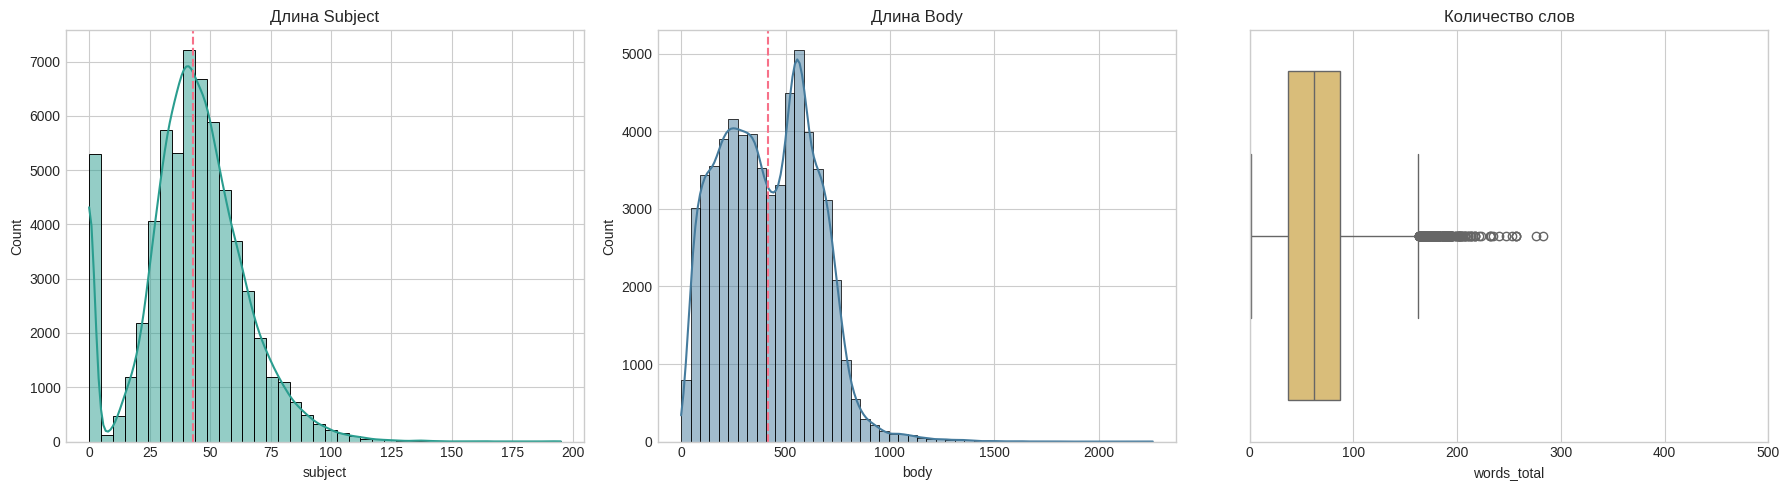

Subject median: 43
Body median: 415
Words median: 62
>512 слов: 0.0%


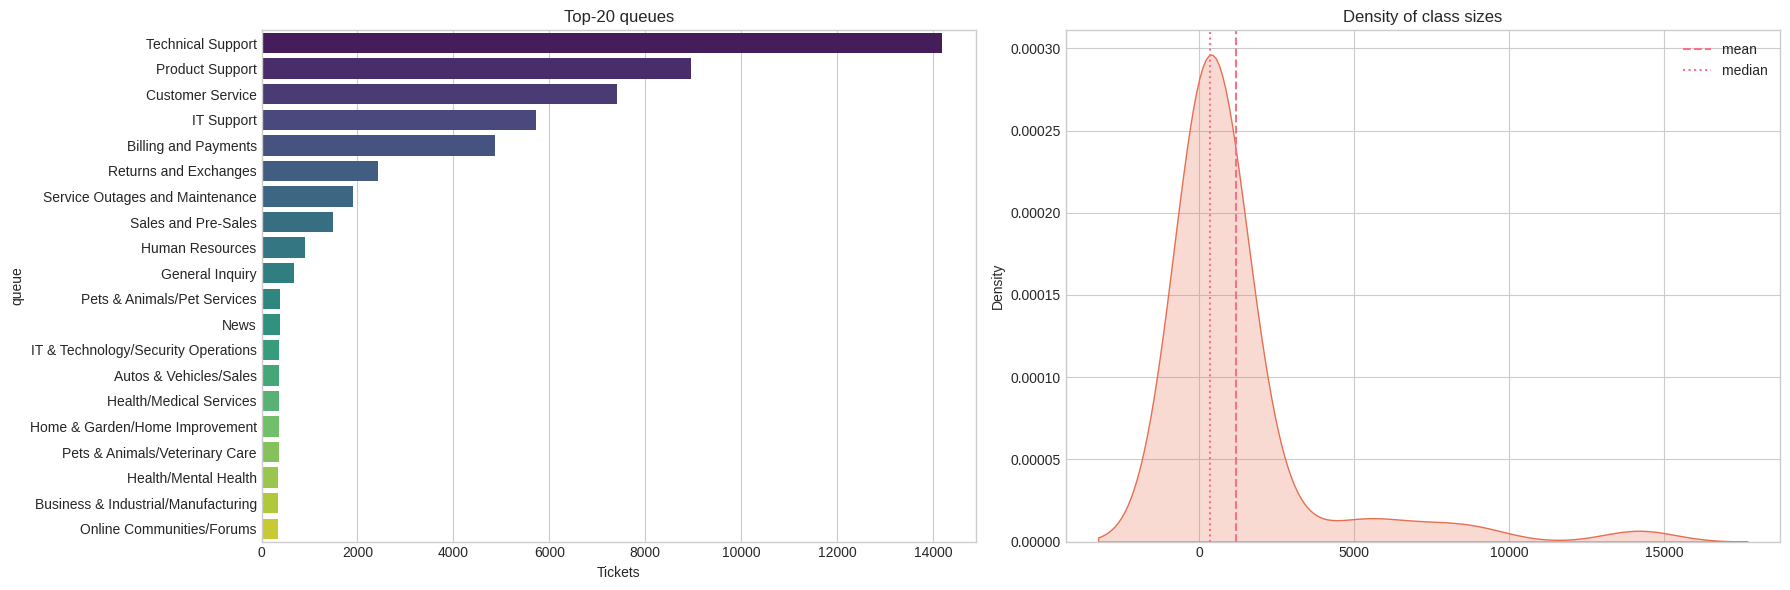

Most frequent: Technical Support 14186
Least frequent: Real Estate 230
Imbalance: 61.7 x


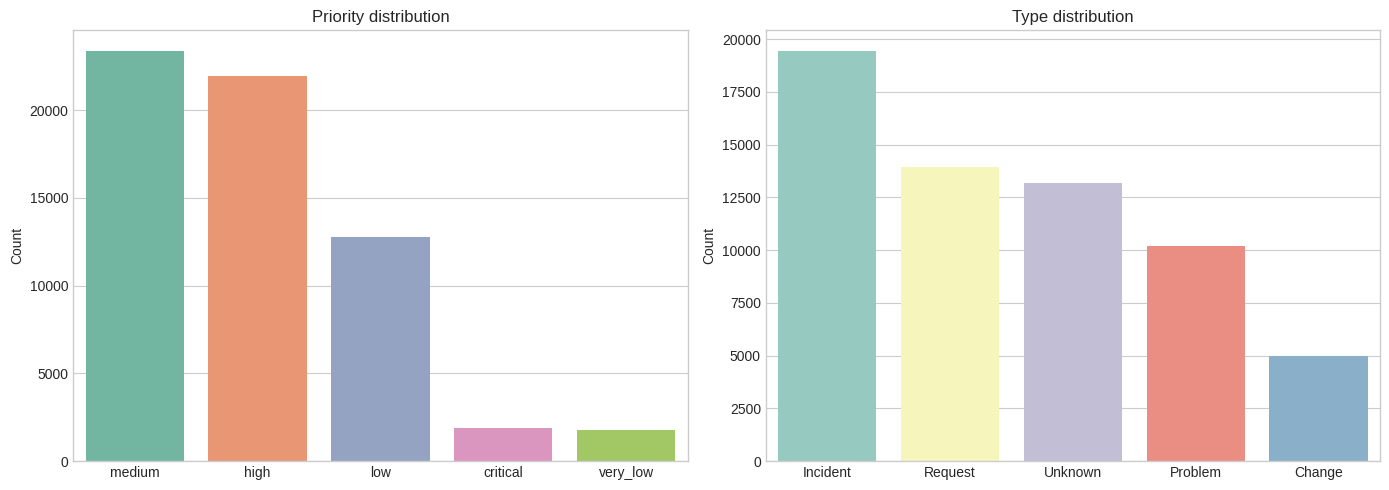

In [7]:

# ---------- Текстовые признаки ----------
df["full_text"] = df[["subject", "body"]].fillna("").agg(" ".join, axis=1)
df["chars_total"] = df["full_text"].str.len()
df["words_total"] = df["full_text"].str.split().str.len()

sub_len = df["subject"].fillna("").str.len()
body_len = df["body"].fillna("").str.len()

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(sub_len[sub_len < 200], bins=40, kde=True, ax=ax[0], color="#2a9d8f")
ax[0].set_title("Длина Subject")
ax[0].axvline(sub_len.median(), linestyle="--")

sns.histplot(body_len[body_len < 3000], bins=50, kde=True, ax=ax[1], color="#457b9d")
ax[1].set_title("Длина Body")
ax[1].axvline(body_len.median(), linestyle="--")

sns.boxplot(x=df["words_total"], ax=ax[2], color="#e9c46a")
ax[2].set_xlim(0, 500)
ax[2].set_title("Количество слов")

plt.tight_layout()
plt.savefig("eda_text_stats.png", dpi=150)
plt.show()

print(f"Subject median: {sub_len.median():.0f}")
print(f"Body median: {body_len.median():.0f}")
print(f"Words median: {df['words_total'].median():.0f}")
print(f">512 слов: {(df['words_total']>512).mean()*100:.1f}%")


# ---------- Распределение queue ----------
queue_freq = df["queue"].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    y=queue_freq.head(20).index,
    x=queue_freq.head(20).values,
    ax=ax[0],
    palette="viridis"
)
ax[0].set_title("Top-20 queues")
ax[0].set_xlabel("Tickets")

sns.kdeplot(queue_freq.values, fill=True, ax=ax[1], color="#e76f51")
ax[1].set_title("Density of class sizes")
ax[1].axvline(queue_freq.mean(), linestyle="--", label="mean")
ax[1].axvline(queue_freq.median(), linestyle=":", label="median")
ax[1].legend()

plt.tight_layout()
plt.savefig("eda_queue.png", dpi=150)
plt.show()

print("Most frequent:", queue_freq.idxmax(), queue_freq.max())
print("Least frequent:", queue_freq.idxmin(), queue_freq.min())
print("Imbalance:", round(queue_freq.max()/queue_freq.min(),1),"x")


# ---------- Priority и Type ----------
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.countplot(
    data=df,
    x="priority",
    order=df["priority"].value_counts().index,
    ax=ax[0],
    palette="Set2"
)
ax[0].set_title("Priority distribution")

sns.countplot(
    data=df.fillna({"type":"Unknown"}),
    x="type",
    order=df["type"].fillna("Unknown").value_counts().index,
    ax=ax[1],
    palette="Set3"
)
ax[1].set_title("Type distribution")

for a in ax:
    a.set_xlabel("")
    a.set_ylabel("Count")

plt.tight_layout()
plt.savefig("eda_priority_type.png", dpi=150)
plt.show()

### Видим дизбаланс классов

# 4. Очистка

In [8]:

# Набор регулярных выражений для очистки
CLEAN_PATTERNS = [
    (r'<[^>]*>', ' '),                 # HTML
    (r'\S+@\S+', ' EMAIL '),           # email
    (r'http\S+|www\.\S+', ' URL '),    # URL
    (r'\b\d{1,3}(?:\.\d{1,3}){3}\b', ' IP '),  # IP
    (r'\b[A-Z]+-\d+\b', ' TICKET ')    # ticket id
]

def normalize_ticket(text):
    """Нормализация текста тикета."""
    
    if not isinstance(text, str):
        return ""

    # Unicode normalization
    text = unicodedata.normalize("NFKC", text)

    # переводим управляющие символы в пробел
    text = text.replace("\n", " ").replace("\t", " ").replace("\r", " ")

    # применяем regex правила
    for pattern, repl in CLEAN_PATTERNS:
        text = re.sub(pattern, repl, text)

    # финальная нормализация пробелов
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# ===== применяем к датасетам =====
for frame in (df_train, df_val, df_test):
    frame["text_clean"] = frame["text"].map(normalize_ticket)


# ===== пример =====
sample_before = df_train["text"].iloc[0][:200]
sample_after  = df_train["text_clean"].iloc[0][:200]

print("До очистки:\n", sample_before)
print("\nПосле очистки:\n", sample_after)

До очистки:
 Wesentlicher Sicherheitsvorfall Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene G

После очистки:
 Wesentlicher Sicherheitsvorfall Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene G


# 5. Baseline model: TF-IDF + linear model

In [9]:
# ================================
# Подготовка данных
# ================================

print("Подготовка признаков...")

X_train = df_train["text_clean"]
X_valid = df_val["text_clean"]
X_test  = df_test["text_clean"]

targets = {
    "queue": (
        df_train["queue_id"],
        df_val["queue_id"],
        df_test["queue_id"]
    ),
    "priority": (
        df_train["priority_id"],
        df_val["priority_id"],
        df_test["priority_id"]
    ),
    "type": (
        df_train["type_id"],
        df_val["type_id"],
        df_test["type_id"]
    )
}

print("Строим TF-IDF представление...")

vectorizer = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1,2),
    min_df=2,
    analyzer="word",
    sublinear_tf=True,
    strip_accents="unicode",
    token_pattern=r"(?u)\b\w+\b"
)

Xtr = vectorizer.fit_transform(X_train)
Xva = vectorizer.transform(X_valid)
Xte = vectorizer.transform(X_test)

print("TF-IDF shape:", Xtr.shape)

Подготовка признаков...
Строим TF-IDF представление...
TF-IDF shape: (49412, 100000)


In [10]:
# ================================
# Метрика задания
# ================================

def evaluate(q_true, q_pred, p_true, p_pred, t_true, t_pred):

    f1_q = f1_score(q_true, q_pred, average="macro", zero_division=0)

    acc_q = accuracy_score(q_true, q_pred)
    acc_p = accuracy_score(p_true, p_pred)
    acc_t = accuracy_score(t_true, t_pred)

    final = 0.70*f1_q + 0.15*acc_p + 0.15*acc_t

    return {
        "Score": round(final,4),
        "MacroF1(queue)": round(f1_q,4),
        "Acc(queue)": round(acc_q,4),
        "Acc(priority)": round(acc_p,4),
        "Acc(type)": round(acc_t,4)
    }


# ================================
# Logistic Regression baseline
# ================================

print("Обучение Logistic Regression baseline...")

models = {
    name: LogisticRegression(
        solver="saga",
        C=5.0,
        max_iter=1000,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )
    for name in ["queue","priority","type"]
}

# обучение
models["queue"].fit(Xtr, targets["queue"][0])
models["priority"].fit(Xtr, targets["priority"][0])
models["type"].fit(Xtr, targets["type"][0])

# предсказания
pred_q = models["queue"].predict(Xva)
pred_p = models["priority"].predict(Xva)
pred_t = models["type"].predict(Xva)

results = evaluate(
    targets["queue"][1], pred_q,
    targets["priority"][1], pred_p,
    targets["type"][1], pred_t
)

print("\nVAL результаты:")
for k,v in results.items():
    print(f"{k}: {v}")

Обучение Logistic Regression baseline...

VAL результаты:
Score: 0.8428
MacroF1(queue): 0.8692
Acc(queue): 0.6018
Acc(priority): 0.6789
Acc(type): 0.8834


# 6. multitask Transformer-модель

In [13]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ===== Основные гиперпараметры =====

MODEL_NAME = "xlm-roberta-base"

MAX_LENGTH = 256    
TRAIN_BS   = 32
EVAL_BS    = 64
NUM_EPOCHS = 9        
LR_BASE    = 2.2e-5   
WARMUP_FRAC = 0.08    


N_QUEUE = len(encoders["queue"].classes_)
N_PRIORITY = len(encoders["priority"].classes_)
N_TYPE = len(encoders["type"].classes_)

print(f"Classes → queue={N_QUEUE}, priority={N_PRIORITY}, type={N_TYPE}")

Device: cuda
GPU: Tesla T4
Classes → queue=52, priority=5, type=5


### Dataset для тикетов

In [14]:
class TicketDataset(Dataset):

    def __init__(self, frame, tokenizer, max_len=MAX_LENGTH):

        self.texts = frame["text_clean"].values

        self.labels_queue = frame["queue_id"].values
        self.labels_prio  = frame["priority_id"].values
        self.labels_type  = frame["type_id"].values

        self.tokenizer = tokenizer
        self.max_len   = max_len


    def __len__(self):
        return len(self.texts)


    def __getitem__(self, idx):

        encoded = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoded["input_ids"].squeeze(),
            "attention_mask": encoded["attention_mask"].squeeze(),
            "queue_label": torch.tensor(self.labels_queue[idx], dtype=torch.long),
            "priority_label": torch.tensor(self.labels_prio[idx], dtype=torch.long),
            "type_label": torch.tensor(self.labels_type[idx], dtype=torch.long)
        }

        return item

### Multitask Transformer модель

In [15]:
class TicketMultiTaskModel(nn.Module):

    def __init__(self, backbone, n_q, n_p, n_t, dropout=0.25):

        super().__init__()

        self.encoder = AutoModel.from_pretrained(backbone)
        hidden = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)

        # головы классификации

        self.queue_head = nn.Sequential(
            nn.Linear(hidden, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, n_q)
        )

        self.priority_head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_p)
        )

        self.type_head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_t)
        )


    def forward(self, ids, mask):

        out = self.encoder(input_ids=ids, attention_mask=mask)

        pooled = out.last_hidden_state[:, 0]
        pooled = self.dropout(pooled)

        q_logits = self.queue_head(pooled)
        p_logits = self.priority_head(pooled)
        t_logits = self.type_head(pooled)

        return q_logits, p_logits, t_logits

### Токенизация и DataLoader

In [16]:
print("Loading tokenizer:", MODEL_NAME)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = TicketDataset(df_train, tokenizer)
val_ds   = TicketDataset(df_val, tokenizer)
test_ds  = TicketDataset(df_test, tokenizer)

train_loader = DataLoader(
    train_ds,
    batch_size=TRAIN_BS,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=EVAL_BS,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=EVAL_BS,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Loading tokenizer: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 1545
Val batches: 97


### Class weights для дисбаланса

In [17]:
def compute_weights(labels, n_classes):

    counts = np.bincount(labels, minlength=n_classes)
    counts = np.maximum(counts, 1)

    w = 1.0 / counts
    w = w / w.sum() * n_classes

    return torch.tensor(w, dtype=torch.float32)


w_queue = compute_weights(df_train["queue_id"].values, N_QUEUE).to(DEVICE)
w_prio  = compute_weights(df_train["priority_id"].values, N_PRIORITY).to(DEVICE)
w_type  = compute_weights(df_train["type_id"].values, N_TYPE).to(DEVICE)

loss_queue = nn.CrossEntropyLoss(weight=w_queue, label_smoothing=0.08)
loss_prio  = nn.CrossEntropyLoss(weight=w_prio, label_smoothing=0.08)
loss_type  = nn.CrossEntropyLoss(weight=w_type, label_smoothing=0.08)

### Инициализация модели и optimizer

In [18]:
print("Initializing model...")

model = TicketMultiTaskModel(
    MODEL_NAME,
    N_QUEUE,
    N_PRIORITY,
    N_TYPE,
    dropout=0.25
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total params:", f"{total_params:,}")
print("Trainable:", f"{trainable_params:,}")


optimizer = AdamW([
    {"params": model.encoder.parameters(), "lr": LR_BASE},
    {"params": model.queue_head.parameters(), "lr": LR_BASE * 8},
    {"params": model.priority_head.parameters(), "lr": LR_BASE * 8},
    {"params": model.type_head.parameters(), "lr": LR_BASE * 8}
], weight_decay=0.01)

Initializing model...


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params: 278,860,350
Trainable: 278,860,350


### Scheduler

In [19]:
total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_FRAC)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    warmup_steps,
    total_steps
)

print("Training steps:", total_steps)
print("Warmup steps:", warmup_steps)

Training steps: 13905
Warmup steps: 1112


### Функции обучения и оценки

In [28]:
TASK_IMPORTANCE = {"queue": 0.5, "priority": 0.35, "type": 0.15}


def train_one_epoch(model, loader):

    model.train()
    total_loss = 0

    preds_q, preds_p, preds_t = [], [], []
    yq_all, yp_all, yt_all = [], [], []

    for batch in loader:

        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)

        yq = batch["queue_label"].to(DEVICE)
        yp = batch["priority_label"].to(DEVICE)
        yt = batch["type_label"].to(DEVICE)

        optimizer.zero_grad()

        q_log, p_log, t_log = model(ids, mask)

        lq = loss_queue(q_log, yq)
        lp = loss_prio(p_log, yp)
        lt = loss_type(t_log, yt)

        loss = (
            TASK_IMPORTANCE["queue"] * lq +
            TASK_IMPORTANCE["priority"] * lp +
            TASK_IMPORTANCE["type"] * lt
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds_q.extend(q_log.argmax(1).cpu().numpy())
        preds_p.extend(p_log.argmax(1).cpu().numpy())
        preds_t.extend(t_log.argmax(1).cpu().numpy())

        yq_all.extend(yq.cpu().numpy())
        yp_all.extend(yp.cpu().numpy())
        yt_all.extend(yt.cpu().numpy())

    metrics = evaluate(yq_all, preds_q, yp_all, preds_p, yt_all, preds_t)

    return total_loss / len(loader), metrics

### Evaluation

In [29]:
@torch.no_grad()
def evaluate_model(model, loader):

    model.eval()

    pq, pp, pt = [], [], []
    yq, yp, yt = [], [], []

    for batch in loader:

        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)

        q_log, p_log, t_log = model(ids, mask)

        pq.extend(q_log.argmax(1).cpu().numpy())
        pp.extend(p_log.argmax(1).cpu().numpy())
        pt.extend(t_log.argmax(1).cpu().numpy())

        yq.extend(batch["queue_label"].numpy())
        yp.extend(batch["priority_label"].numpy())
        yt.extend(batch["type_label"].numpy())

    metrics = evaluate(yq, pq, yp, pp, yt, pt)

    return metrics

### Обучение

In [30]:


best_score = 0
best_model_path = "best_model.pt"

print("Start training...\n")

for epoch in range(1, NUM_EPOCHS + 1):

    t0 = time.time()

    train_loss, train_metrics = train_one_epoch(model, train_loader)

    val_metrics = evaluate_model(model, val_loader)

    elapsed = time.time() - t0

    if val_metrics["Score"] > best_score:
        best_score = val_metrics["Score"]
        torch.save(model.state_dict(), best_model_path)
        mark = "  ← best"
    else:
        mark = ""

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"loss {train_loss:.4f} | "
        f"val_score {val_metrics['Score']:.4f} "
        f"(F1={val_metrics['MacroF1(queue)']:.4f}) "
        f"[{elapsed:.0f}s]{mark}"
    )

print("\nTraining finished")
print("Best validation score:", best_score)

Start training...

Epoch 1/9 | loss 1.5617 | val_score 0.7801 (F1=0.8270) [2480s]  ← best
Epoch 2/9 | loss 1.4971 | val_score 0.8045 (F1=0.8462) [2490s]  ← best
Epoch 3/9 | loss 1.4376 | val_score 0.8133 (F1=0.8585) [2490s]  ← best
Epoch 4/9 | loss 1.3955 | val_score 0.8264 (F1=0.8624) [2487s]  ← best
Epoch 5/9 | loss 1.3690 | val_score 0.8350 (F1=0.8697) [2486s]  ← best
Epoch 6/9 | loss 1.3508 | val_score 0.8376 (F1=0.8715) [2488s]  ← best
Epoch 7/9 | loss 1.3414 | val_score 0.8390 (F1=0.8730) [2487s]  ← best
Epoch 8/9 | loss 1.3390 | val_score 0.8395 (F1=0.8733) [2487s]  ← best
Epoch 9/9 | loss 1.3368 | val_score 0.8398 (F1=0.8730) [2487s]  ← best

Training finished
Best validation score: 0.8398


##  Попробовал ещё несколько bert моделей, скор оказался хуже
